Step 1: Import and Load Dataset

In [4]:
!pip install lazypredict

   ---------------------------------------- 0.0/8.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.8 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/8.8 MB 3.0 MB/s eta 0:00:03
   -------- ------------------------------- 1.8/8.8 MB 3.1 MB/s eta 0:00:03
   ----------- ---------------------------- 2.6/8.8 MB 3.4 MB/s eta 0:00:02
   ----------------- ---------------------- 3.9/8.8 MB 4.0 MB/s eta 0:00:02
   ------------------------- -------------- 5.5/8.8 MB 4.6 MB/s eta 0:00:01
   --------------------------- ------------ 6.0/8.8 MB 4.6 MB/s eta 0:00:01
   --------------------------------- ------ 7.3/8.8 MB 4.6 MB/s eta 0:00:01
   ------------------------------------- -- 8.1/8.8 MB 4.5 MB/s eta 0:00:01
   ---------------------------------------- 8.8/8.8 MB 4.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ------------- -------------------------- 0.8/2.3 MB 4.2 MB/s eta 0:00:01
   --------------------------- --

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load the dataset
train = pd.read_csv("train.csv")






In [6]:
# Check the first few rows
print("----- HEAD -----")
train.head()

----- HEAD -----


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.00,False,0.00,0.00,0.00,0.00,0.00,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.00,False,109.00,9.00,25.00,549.00,44.00,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.00,True,43.00,3576.00,0.00,6715.00,49.00,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.00,False,0.00,1283.00,371.00,3329.00,193.00,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.00,False,303.00,70.00,151.00,565.00,2.00,Willy Santantines,True


In [7]:
# Basic info
print("\n----- INFO -----")
train.info()


----- INFO -----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


Step 2: Visual Analysis (Graphs)

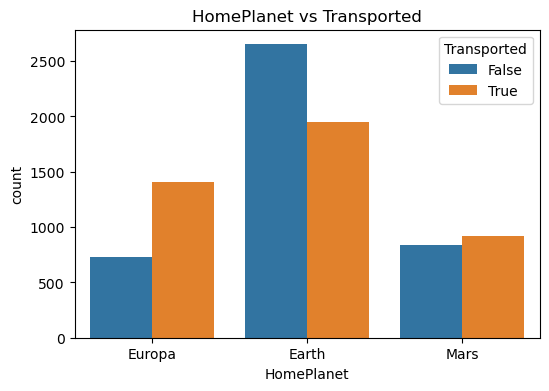

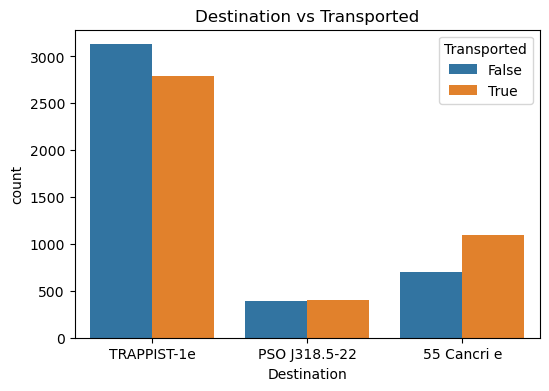

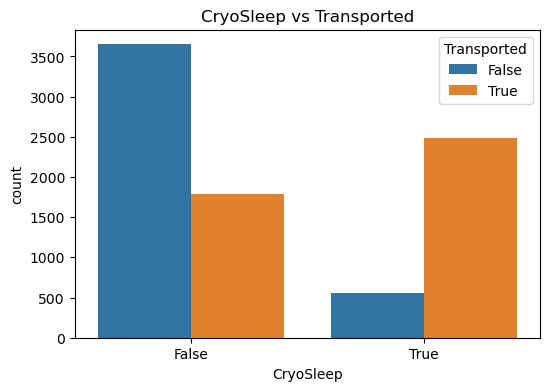

In [8]:
# Plot categorical distributions vs target
categorical_cols = ['HomePlanet', 'Destination', 'CryoSleep']

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=train, x=col, hue='Transported')
    plt.title(f'{col} vs Transported')
    plt.show()


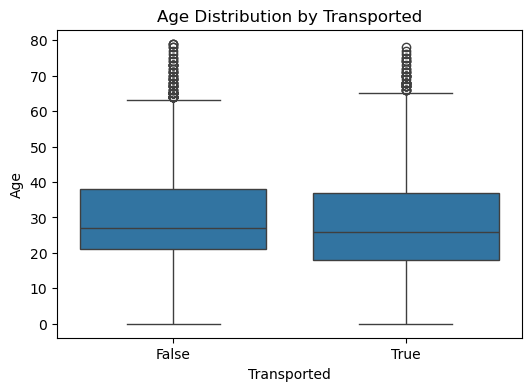

In [9]:
plt.figure(figsize=(6,4))
sns.boxplot(data=train, x='Transported', y='Age')
plt.title('Age Distribution by Transported')
plt.show()


Step 3: Data Cleaning and Preprocessing

In [10]:
train = train.drop(['PassengerId', 'Cabin', 'Name'], axis=1)


In [20]:
train['CryoSleep'] = train['CryoSleep'].map({True:1, False:0})


In [21]:
for col in train.columns:
    if train[col].dtype in ['float64', 'int64']:
        train[col].fillna(train[col].mean(), inplace=True)
    else:
        train[col].fillna(train[col].mode()[0], inplace=True)


In [22]:
train = pd.get_dummies(train, columns=['HomePlanet', 'Destination'], drop_first=True)


In [23]:
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
train['TotalSpendings'] = train[spending_cols].sum(axis=1)

# Drop the individual spending columns
train.drop(spending_cols, axis=1, inplace=True)


Step 4: Correlation Matrix

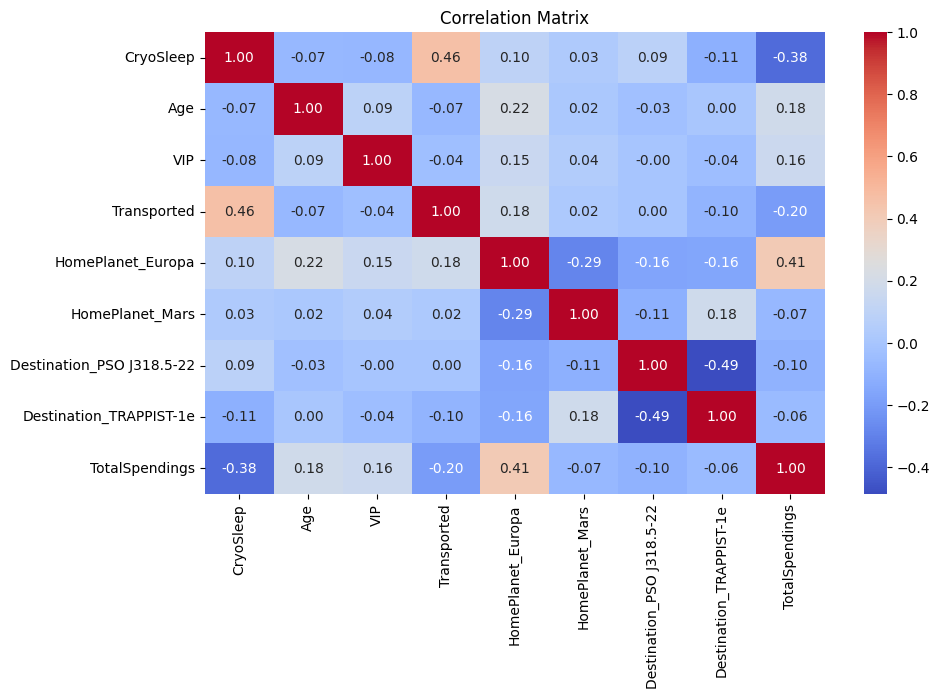

In [24]:
plt.figure(figsize=(10,6))
corr = train.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


In [25]:
# Convert target to int (if it’s boolean)
train['Transported'] = train['Transported'].map({True:1, False:0})

X = train.drop('Transported', axis=1)
y = train['Transported']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Step 5: Model with LazyPredict

In [26]:
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

print(models)


100%|██████████| 32/32 [00:06<00:00,  4.90it/s]

[LightGBM] [Info] Number of positive: 3500, number of negative: 3454
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000269 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 339
[LightGBM] [Info] Number of data points in the train set: 6954, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503307 -> initscore=0.013230
[LightGBM] [Info] Start training from score 0.013230
                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
LabelSpreading                     0.74               0.74     0.74      0.74   
SVC                                0.74               0.74     0.74      0.73   
LabelPropagation                   0.74               0.74     0.74      0.74   
AdaBoostClassifier                 0.74               0.74     0.74      0.74   
LGBMClassifier             